# Bài 1: Đếm số lượng hạt gạo (Rice Counting)

**Mục tiêu:** Tạo 1 chuỗi xử lý chung (pipeline) để đếm số hạt gạo trong tất cả các ảnh đầu vào (kể cả ảnh nhiễu, ảnh chênh sáng).

## 1. Import thư viện

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Thiết lập kích thước hiển thị ảnh mặc định cho matplotlib
plt.rcParams['figure.figsize'] = (10, 8)

## 2. Load ảnh đầu vào
Chúng ta sẽ load 4 bức ảnh từ thư mục `Proj1.2`.

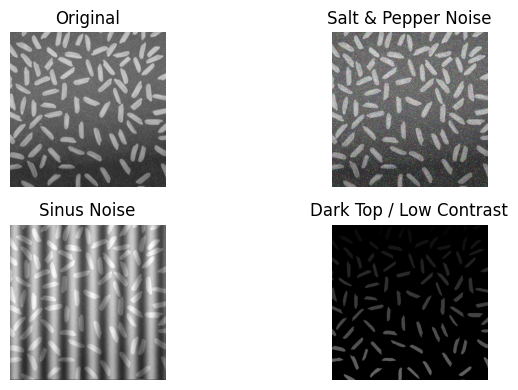

In [9]:
image_folder = 'Proj1.2'
image_paths = [
    os.path.join(image_folder, '1_wIXlvBeAFtNVgJd49VObgQ.png'),
    os.path.join(image_folder, '1_wIXlvBeAFtNVgJd49VObgQ.png_Salt_Pepper_Noise1.png'),
    os.path.join(image_folder, '1_wIXlvBeAFtNVgJd49VObgQ_sinus.png'),
    os.path.join(image_folder, '1_zd6ypc20QAIFMzrbCmJRMg.png')
]

titles = ['Original', 'Salt & Pepper Noise', 'Sinus Noise', 'Dark Top / Low Contrast']

# Đọc và hiển thị 4 ảnh
fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    # Đọc ảnh bằng OpenCV (mặc định là BGR)
    img = cv2.imread(image_paths[i])
    # Chuyển BGR sang RGB để hiển thị đúng màu trên matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img_rgb)
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

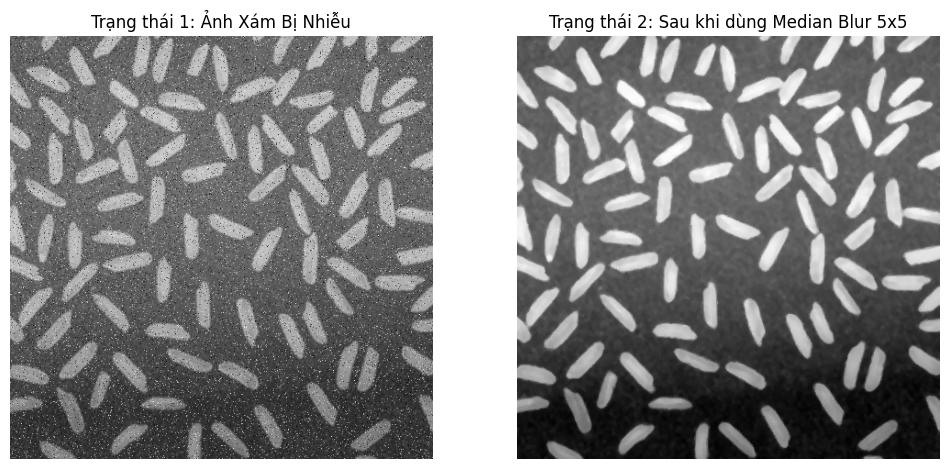

In [10]:
test_img_path = image_paths[1] 
img_nhap = cv2.imread(test_img_path)

img_gray = cv2.cvtColor(img_nhap, cv2.COLOR_BGR2GRAY)
img_blurred = cv2.medianBlur(img_gray, 5)

# Khởi tạo 2 ô để vẽ so sánh Before - After
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Trạng thái 1: Ảnh Xám Bị Nhiễu')
axes[0].axis('off')

axes[1].imshow(img_blurred, cmap='gray')
axes[1].set_title('Trạng thái 2: Sau khi dùng Median Blur 5x5')
axes[1].axis('off')

plt.show()

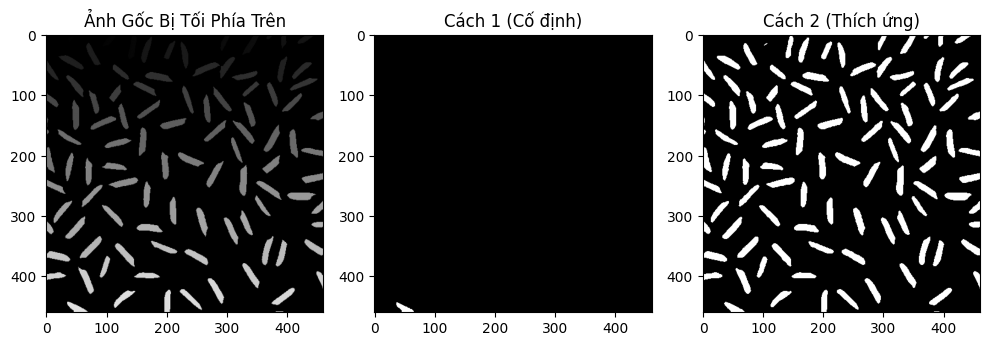

In [16]:
test_img_path = image_paths[3] 
img_nhap = cv2.imread(test_img_path)
gray = cv2.cvtColor(img_nhap, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray, 5)

_,thresh_thuong = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)

thresh_thich_ung = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                         cv2.THRESH_BINARY, 71, -1)

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Ảnh Gốc Bị Tối Phía Trên')

axes[1].imshow(thresh_thuong, cmap='gray')
axes[1].set_title('Cách 1 (Cố định)')

axes[2].imshow(thresh_thich_ung, cmap='gray')
axes[2].set_title('Cách 2 (Thích ứng)')

plt.tight_layout()
plt.show()